In [45]:
from langgraph.graph import StateGraph, START, END, MessagesState
from langchain_groq import ChatGroq
from dotenv import load_dotenv
from typing import TypedDict, Annotated
from langchain_core.messages import HumanMessage, BaseMessage
from langgraph.graph.message import add_messages

In [46]:
load_dotenv()

True

In [47]:
llm = ChatGroq(model='llama-3.3-70b-versatile')

In [48]:
class ChatState(TypedDict):
    messages: Annotated[list[BaseMessage], add_messages]

In [49]:
def call_mode(state: ChatState): # by default MessagesState
    messages = state['messages']
    response = llm.invoke(messages)
    
    return {
        'messages': [response]
    }

In [50]:
graph = StateGraph(ChatState)

graph.add_node('call_mode', call_mode)

graph.add_edge(START, 'call_mode')
graph.add_edge('call_mode', END)

workflow = graph.compile()

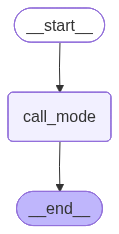

In [51]:
workflow

In [53]:
workflow.invoke({'messages':[{'role':'user', 'content': 'Hi my name is Wijad Ullah'}]})

{'messages': [HumanMessage(content='Hi my name is Wijad Ullah', additional_kwargs={}, response_metadata={}, id='19ab0e10-d817-4523-a5c2-3cd367f8ba70'),
  AIMessage(content="Hello Wijad Ullah, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 45, 'total_tokens': 76, 'completion_time': 0.057964986, 'completion_tokens_details': None, 'prompt_time': 0.006218035, 'prompt_tokens_details': None, 'queue_time': 0.008539252, 'total_time': 0.064183021}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f175f-ab7a-7fa1-b12e-6ad465247efd-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 45, 'output_tokens': 31, 'total_tokens': 76})]}

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [54]:
workflow.invoke({'messages':[{'role':'user', 'content': 'What is mu name?'}]})

{'messages': [HumanMessage(content='What is mu name?', additional_kwargs={}, response_metadata={}, id='a2a32c99-e296-46b0-9dd4-24de329faa14'),
  AIMessage(content="I don't know your name. I'm a large language model, I don't have the ability to retain information about individual users, and our conversation just started. If you'd like to share your name, I'd be happy to chat with you and use it in our conversation!", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 58, 'prompt_tokens': 40, 'total_tokens': 98, 'completion_time': 0.161679908, 'completion_tokens_details': None, 'prompt_time': 0.001725587, 'prompt_tokens_details': None, 'queue_time': 0.008426552, 'total_time': 0.163405495}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1760-7493-7610-a123-75af39aa34ce-0', tool_calls=[], invalid_tool_calls=[], usage_

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


ADD CHECKPOINTER

In [55]:
def call_mode(state: ChatState):
    messages = state['messages']
    response = llm.invoke(messages)
    
    return {
        'messages': [response]
    }

In [59]:
graph = StateGraph(ChatState)

graph.add_node('call_mode', call_mode)

graph.add_edge(START, 'call_mode')
graph.add_edge('call_mode', END)

In [60]:
from langgraph.checkpoint.memory import InMemorySaver

checkpointer = InMemorySaver()

In [62]:
chatbot = graph.compile(checkpointer=checkpointer)

In [61]:
config = {'configurable': {'thread_id':'thread_id: 1'}}

In [64]:
chatbot.invoke({'messages': [{'role':'user','content':'Hi my name is Wijad ullah'}]}, config=config)

{'messages': [HumanMessage(content='Hi my name is Wijad ullah', additional_kwargs={}, response_metadata={}, id='dab5efb4-db70-4e49-b110-98a0bd0f39d4'),
  AIMessage(content="Hello Wijad Ullah, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 44, 'total_tokens': 75, 'completion_time': 0.060914841, 'completion_tokens_details': None, 'prompt_time': 0.001839803, 'prompt_tokens_details': None, 'queue_time': 0.008585885, 'total_time': 0.062754644}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1767-5928-7b50-85c7-f16040e3169d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 31, 'total_tokens': 75})]}

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')


In [65]:
chatbot.invoke({'messages': [{'role':'user','content':'What is my name?'}]}, config=config)

{'messages': [HumanMessage(content='Hi my name is Wijad ullah', additional_kwargs={}, response_metadata={}, id='dab5efb4-db70-4e49-b110-98a0bd0f39d4'),
  AIMessage(content="Hello Wijad Ullah, it's nice to meet you. Is there something I can help you with or would you like to chat?", additional_kwargs={}, response_metadata={'token_usage': {'completion_tokens': 31, 'prompt_tokens': 44, 'total_tokens': 75, 'completion_time': 0.060914841, 'completion_tokens_details': None, 'prompt_time': 0.001839803, 'prompt_tokens_details': None, 'queue_time': 0.008585885, 'total_time': 0.062754644}, 'model_name': 'llama-3.3-70b-versatile', 'system_fingerprint': 'fp_dae98b5ecb', 'service_tier': 'on_demand', 'finish_reason': 'stop', 'logprobs': None, 'model_provider': 'groq'}, id='lc_run--019f1767-5928-7b50-85c7-f16040e3169d-0', tool_calls=[], invalid_tool_calls=[], usage_metadata={'input_tokens': 44, 'output_tokens': 31, 'total_tokens': 75}),
  HumanMessage(content='What is my name?', additional_kwargs={},

Failed to send compressed multipart ingest: langsmith.utils.LangSmithError: Failed to POST https://api.smith.langchain.com/runs/multipart in LangSmith API. HTTPError('403 Client Error: Forbidden for url: https://api.smith.langchain.com/runs/multipart', '{"error":"Forbidden"}\n')
